# 64 canales de ARN en una sola imagen

**1.296 combinaciones posibles. El equipo eligió 64.**

Los microscopios de fluorescencia tienen 4 colores. Ver 64 genes distintos en una sola imagen parecía imposible. PRISM lo consigue jugando con la *intensidad* de cada color — y eligiendo con cuidado los 64 puntos más separados del espacio.

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2025-10-30-prism-64-barcodes/notebook.ipynb)

📄 **Paper:** [Huang et al., Nature Biotechnology (2025)](https://doi.org/10.1038/s41587-025-02883-7)
🎥 **Video:** [Ver en YouTube](https://youtube.com/shorts/btbnjawFd44)
💻 **Código:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)


## Contexto

La imagen espacial del ARN — ver *qué gen se expresa en qué célula* dentro de un tejido — es una de las herramientas más poderosas de la biología moderna. El cuello de botella: un microscopio de fluorescencia solo distingue 4 colores a la vez. Los métodos que superan ese límite (MERFISH, seqFISH) requieren decenas de rondas de imagen.

PRISM (*Profiling of RNA In situ through Single-round imaging*) empuja el límite sin añadir rondas: codifica cada ARN con una combinación de 4 canales e *intensidad*. Cada gen queda descrito por un vector de 4 números (uno por canal), eligiendo entre 6 niveles de intensidad (0 a 5). Eso da un espacio de 6⁴ = 1.296 combinaciones posibles. El truco está en elegir cuáles usar.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ALFABETO = 6                 # niveles de intensidad por canal (0 a 5)
CANALES = 4                  # canales de color del microscopio
TOTAL_POSIBLE = ALFABETO ** CANALES  # 1.296
FUENTE = 'Fuente: Huang et al. (2025), Nature Biotechnology | Datos: Supplementary Data 4'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_REFERENCIA = '#D97706'
COLOR_SECUNDARIO = '#059669'
COLOR_GRIS = '#BBBBBB'

# ══════════════════════════════════════════════════════════════
# Setup + carga de datos
# ══════════════════════════════════════════════════════════════
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations, product

# Cargar estilo editorial CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve('https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

DATA = 'datos'
b64 = pd.read_csv(f'{DATA}/barcodes_64.csv')
b31 = pd.read_csv(f'{DATA}/barcodes_31.csv')
paneles = pd.read_csv(f'{DATA}/gene_panels.csv')
hcc_probes = pd.read_csv(f'{DATA}/hcc_probes.csv')

print(f'Codewords 64-plex: {len(b64)}')
print(f'Codewords 31-plex: {len(b31)}')
print(f'Espacio total posible: {TOTAL_POSIBLE} combinaciones ({ALFABETO} niveles ^ {CANALES} canales)')
print(f'Fracción usada 64-plex: {len(b64)/TOTAL_POSIBLE*100:.1f}%')
print(f'Fracción usada 31-plex: {len(b31)/TOTAL_POSIBLE*100:.1f}%')
print()
print('Primeras 5 entradas del panel 64-plex:')
print(b64.head().to_string(index=False))


Codewords 64-plex: 64
Codewords 31-plex: 31
Espacio total posible: 1296 combinaciones (6 niveles ^ 4 canales)
Fracción usada 64-plex: 4.9%
Fracción usada 31-plex: 2.4%

Primeras 5 entradas del panel 64-plex:
 no  barcode  d0  d1  d2  d3  digit_sum  n_nonzero
  1       50   0   0   5   0          5          1
  2     1040   1   0   4   0          5          2
  3     2030   2   0   3   0          5          2
  4     3020   3   0   2   0          5          2
  5     4010   4   0   1   0          5          2


## Aquí está.

Cada cuadrito es una combinación posible. Los azules son los 64 elegidos.

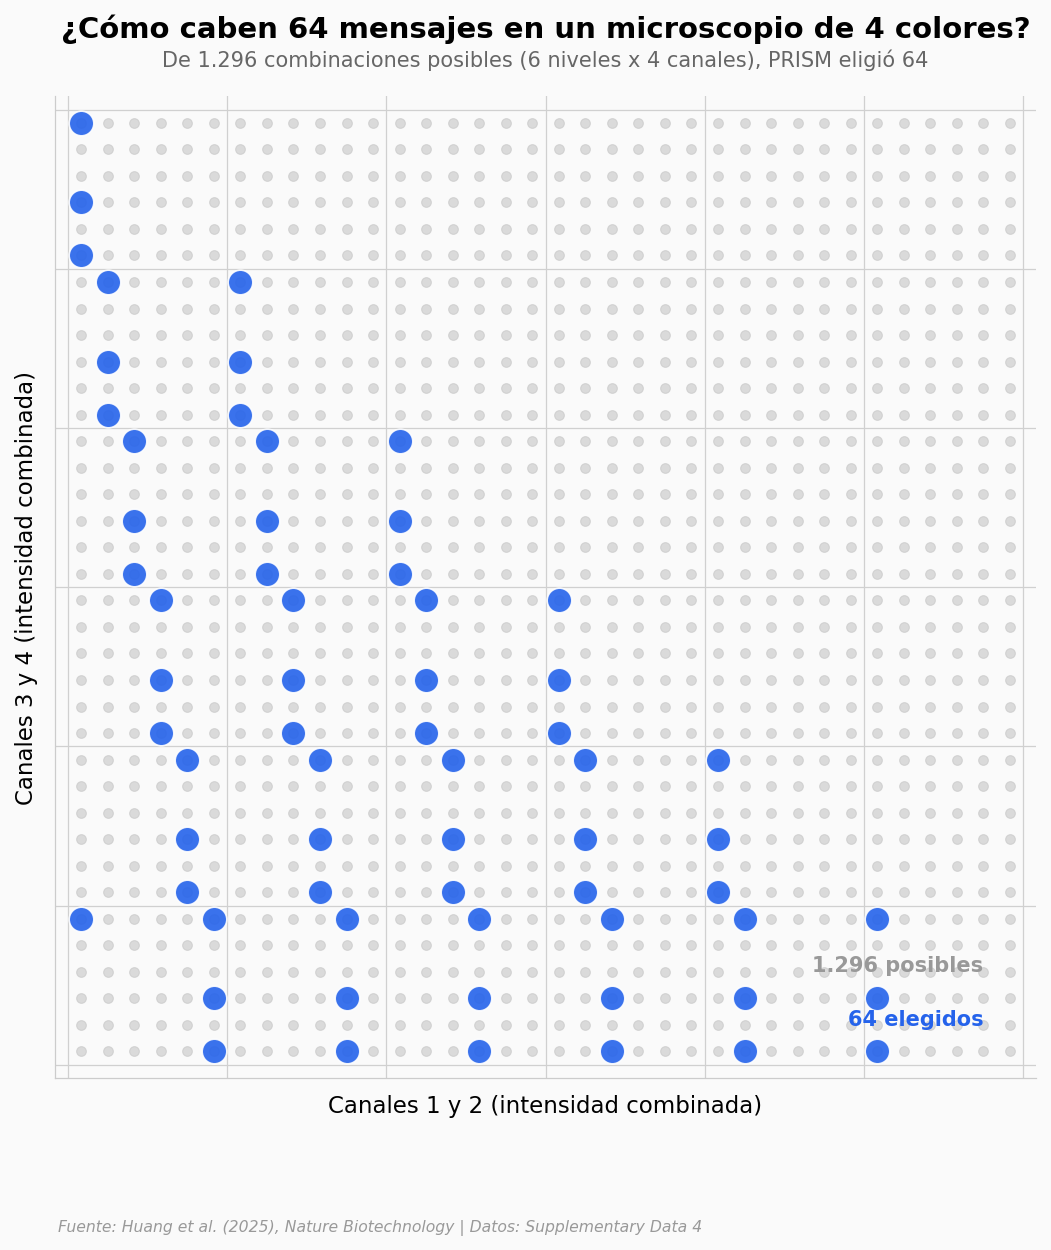

In [2]:
# Proyección 2D del espacio 4D: cada codeword es (d0, d1, d2, d3).
# Mapeamos (d0, d1) -> eje X (6x6 = 36 posiciones) y (d2, d3) -> eje Y.
# Cada una de las 1.296 combinaciones ocupa una celda única.

def proyectar(df):
    x = df['d0'].values * ALFABETO + df['d1'].values
    y = df['d2'].values * ALFABETO + df['d3'].values
    return x, y

# Todas las combinaciones posibles
all_x, all_y = zip(*[(a * ALFABETO + b, c * ALFABETO + d)
                      for a, b, c, d in product(range(ALFABETO), repeat=CANALES)])
x64, y64 = proyectar(b64)

fig, ax = plt.subplots(figsize=(8.5, 8.5))

# Fondo: las 1.296 combinaciones posibles (puntos grises pequeños)
ax.scatter(all_x, all_y, color=COLOR_GRIS, s=22, alpha=0.5, zorder=2)

# Frente: los 64 elegidos
ax.scatter(x64, y64, color=COLOR_DATOS, s=140, alpha=0.9,
           edgecolors='white', linewidths=0.8, zorder=5)

# Gridlines cada 6 para marcar la estructura base-6
for k in range(0, ALFABETO ** 2 + 1, ALFABETO):
    ax.axvline(k - 0.5, color='#D0D0D0', linewidth=0.6, zorder=1)
    ax.axhline(k - 0.5, color='#D0D0D0', linewidth=0.6, zorder=1)

ax.set_title('¿Cómo caben 64 mensajes en un microscopio de 4 colores?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'De 1.296 combinaciones posibles (6 niveles x 4 canales), PRISM eligió 64',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Canales 1 y 2 (intensidad combinada)', fontsize=11)
ax.set_ylabel('Canales 3 y 4 (intensidad combinada)', fontsize=11)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-1, ALFABETO ** 2)
ax.set_ylim(-1, ALFABETO ** 2)
ax.set_aspect('equal')
ax.grid(False)

# Inline labels para los dos grupos
ax.text(34, 3, '1.296 posibles', fontsize=10, color='#999999',
        fontweight='bold', ha='right', zorder=6)
ax.text(34, 1, '64 elegidos', fontsize=10, color=COLOR_DATOS,
        fontweight='bold', ha='right', zorder=6)

fig.text(0.13, -0.01, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/espacio_codewords.png', dpi=200, bbox_inches='tight')
plt.show()


### Lectura guiada

Los puntos azules no están repartidos al azar. PRISM usa una restricción geométrica: solo se eligen codewords cuya suma de intensidades (`d0 + d1 + d2 + d3`) cae en una de **tres capas** fijas — radios 5, 7 y 10. La capa 5 aporta 22 codewords, la 7 otros 21, y la 10 los 21 restantes. Ningún codeword mezcla capas.

Al forzar esa separación por capas, los codewords cercanos en el espacio de color quedan a distancia mínima de √2 ≈ 1,414 unidades de intensidad. Esa distancia es el margen: un píxel ruidoso no puede pasarse de un ARN al siguiente sin cruzar esa frontera. El arte no está en *caber*, está en *separar*.

## ¿Qué tan separados están los codewords?

La pregunta que importa: dado que cada ARN se descifra midiendo intensidad en 4 canales con ruido, ¿cuánto espacio hay entre un ARN y el siguiente? Calculamos la distancia euclidiana entre todos los pares de codewords — son 2.016 pares en el panel 64-plex, y 465 en el 31-plex.

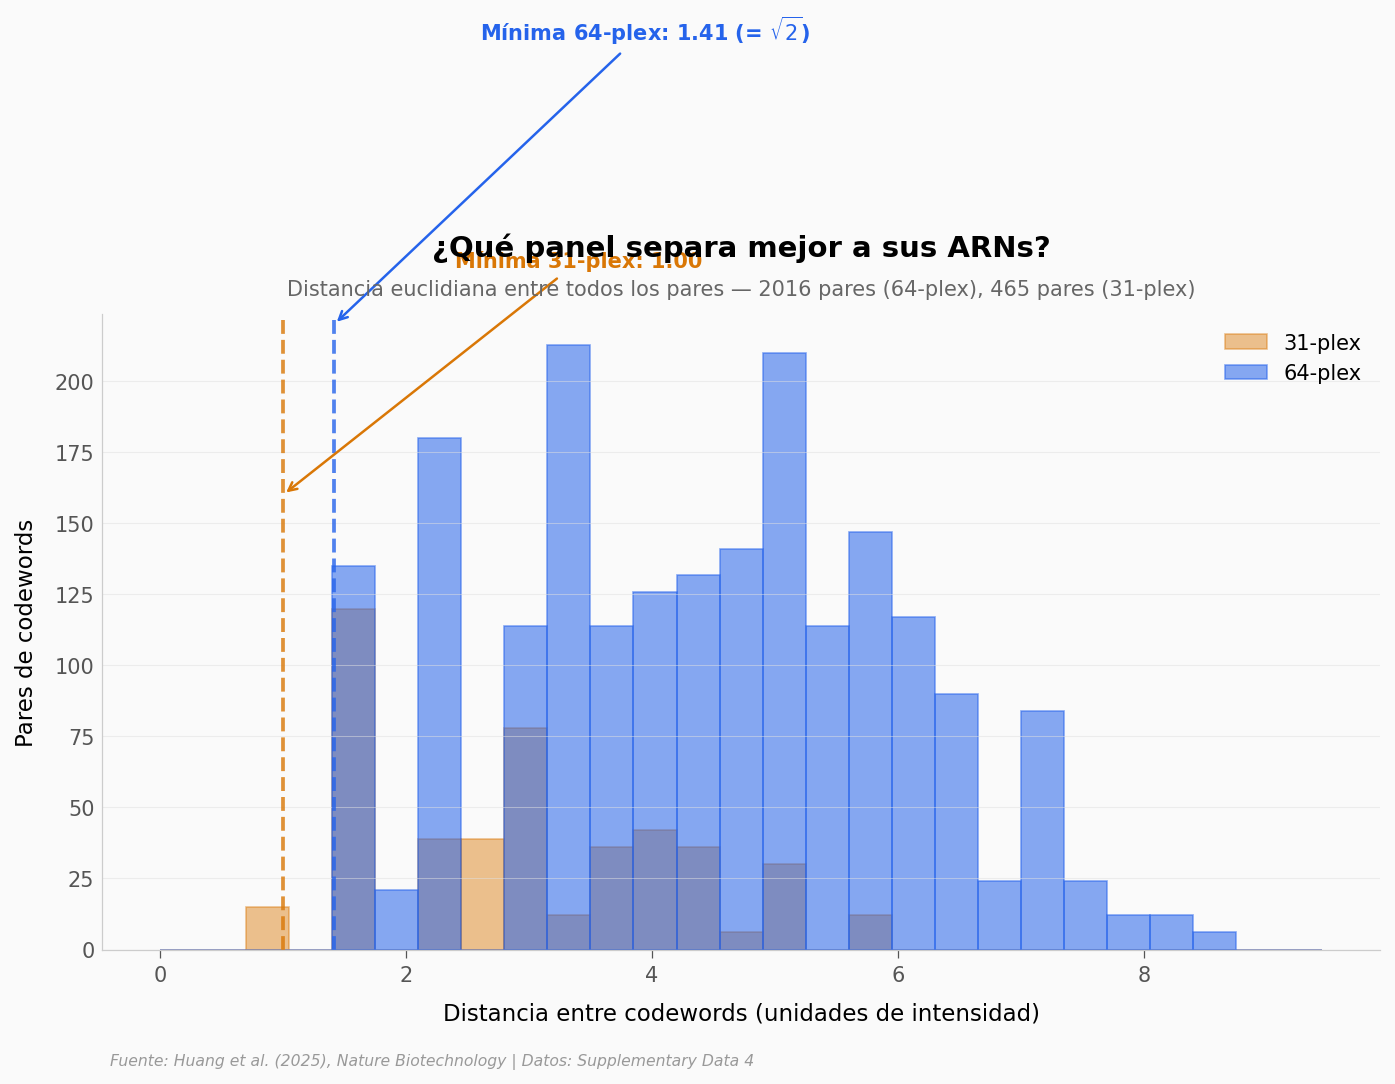

64-plex: mínima 1.414, mediana 4.243, máxima 8.660
         pares a distancia mínima: 135 de 2016
31-plex: mínima 1.000, mediana 2.828, máxima 5.745
         pares a distancia mínima: 15 de 465


In [3]:
def pairwise_dist(df):
    pts = df[['d0', 'd1', 'd2', 'd3']].values
    return np.array([np.sqrt(np.sum((pts[i] - pts[j]) ** 2))
                     for i, j in combinations(range(len(pts)), 2)])

dist64 = pairwise_dist(b64)
dist31 = pairwise_dist(b31)

fig, ax = plt.subplots(figsize=(11, 5.5))

bins = np.arange(0, 9.5, 0.35)
ax.hist(dist31, bins=bins, color=COLOR_REFERENCIA, alpha=0.45,
        edgecolor=COLOR_REFERENCIA, linewidth=0.8, label='31-plex')
ax.hist(dist64, bins=bins, color=COLOR_DATOS, alpha=0.55,
        edgecolor=COLOR_DATOS, linewidth=0.8, label='64-plex')

# Líneas de distancia mínima
ax.axvline(dist31.min(), color=COLOR_REFERENCIA, linewidth=1.8, linestyle='--', alpha=0.8)
ax.axvline(dist64.min(), color=COLOR_DATOS, linewidth=1.8, linestyle='--', alpha=0.8)

ax.annotate(f'Mínima 31-plex: {dist31.min():.2f}',
            xy=(dist31.min(), 160), xytext=(2.4, 240),
            fontsize=10, color=COLOR_REFERENCIA, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.2))
ax.annotate(f'Mínima 64-plex: {dist64.min():.2f} (= $\\sqrt{{2}}$)',
            xy=(dist64.min(), 220), xytext=(2.6, 320),
            fontsize=10, color=COLOR_DATOS, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.2))

ax.set_title('¿Qué panel separa mejor a sus ARNs?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, f'Distancia euclidiana entre todos los pares — {len(dist64)} pares (64-plex), {len(dist31)} pares (31-plex)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Distancia entre codewords (unidades de intensidad)', fontsize=11)
ax.set_ylabel('Pares de codewords', fontsize=11)
ax.legend(loc='upper right', fontsize=10)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distancias_pairwise.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'64-plex: mínima {dist64.min():.3f}, mediana {np.median(dist64):.3f}, máxima {dist64.max():.3f}')
print(f'         pares a distancia mínima: {(dist64 == dist64.min()).sum()} de {len(dist64)}')
print(f'31-plex: mínima {dist31.min():.3f}, mediana {np.median(dist31):.3f}, máxima {dist31.max():.3f}')
print(f'         pares a distancia mínima: {(dist31 == dist31.min()).sum()} de {len(dist31)}')


## Un mismo alfabeto, tres tejidos distintos

El equipo probó PRISM en tres tejidos — cerebro de ratón, embrión de ratón (E12.5-E14.5) y carcinoma hepatocelular humano (HCC, el cáncer de hígado más común). Los codewords son los mismos en los tres casos, pero el *panel de genes* cambia, y la estrategia de **sondas por gen** también. Ahí se ve cómo el método se ajusta a la biología que toque medir.

Genes por panel:
 tejido   panel  n_genes
Cerebro 30-plex       30
Embrion 30-plex       30
Embrion 64-plex       64

HCC: 91 sondas en 31 genes
     media: 2.94 sondas/gen
     genes con 3 sondas: 30, con 1 sonda: 1


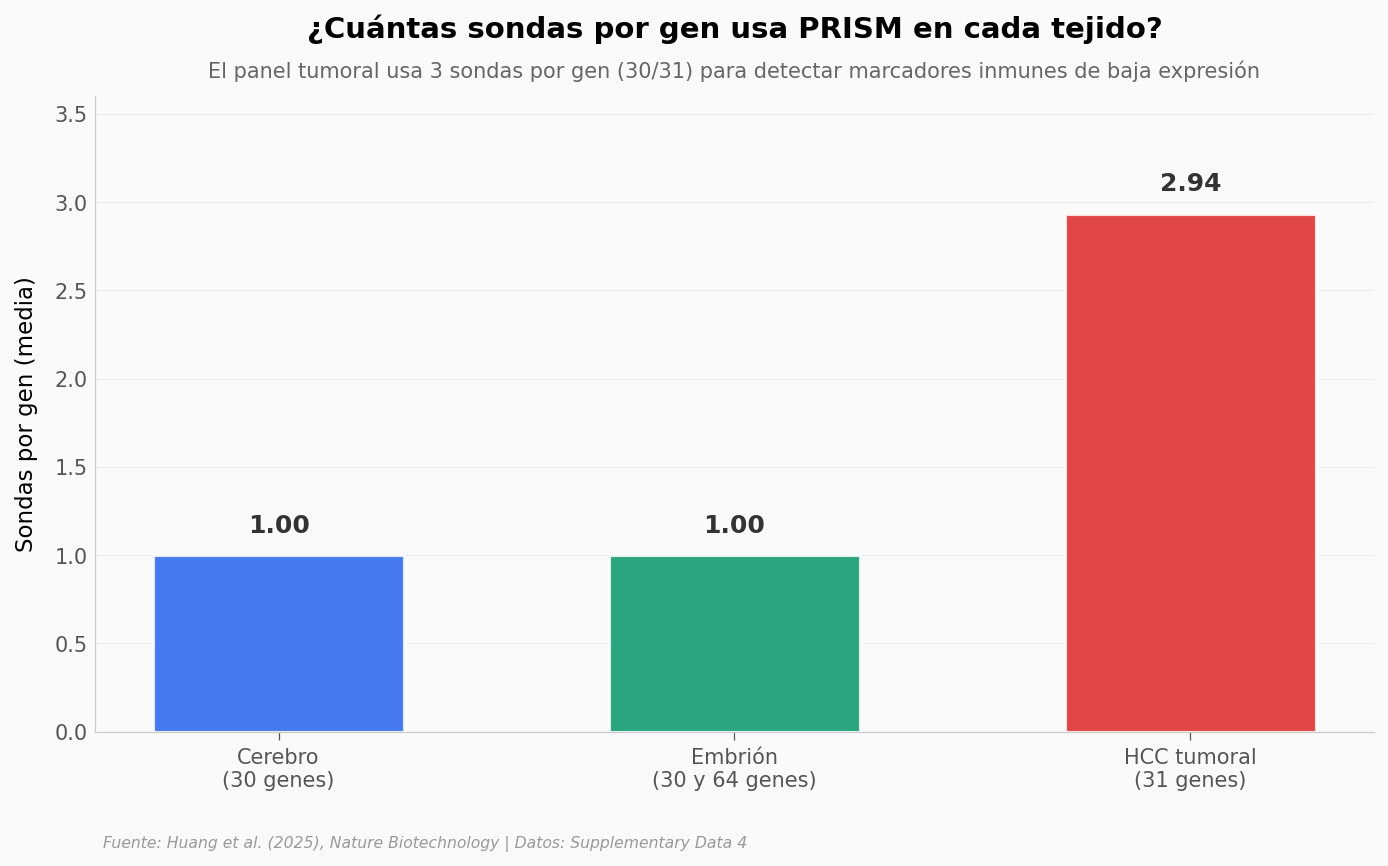

In [4]:
# Probes/gen por tejido
# - Cerebro 30-plex y Embrión 30-plex/64-plex: 1 sonda por gen (sin redundancia)
# - HCC 31-plex: 30 genes con 3 sondas, 1 gen con 1 sonda — redundancia triplicada

panel_sizes = paneles.groupby(['tejido', 'panel']).size().reset_index(name='n_genes')
print('Genes por panel:')
print(panel_sizes.to_string(index=False))
print()
print(f'HCC: {hcc_probes["n_probes"].sum()} sondas en {len(hcc_probes)} genes')
print(f'     media: {hcc_probes["n_probes"].mean():.2f} sondas/gen')
print(f'     genes con 3 sondas: {(hcc_probes["n_probes"] == 3).sum()}, con 1 sonda: {(hcc_probes["n_probes"] == 1).sum()}')

fig, ax = plt.subplots(figsize=(11, 5.5))

# Bar plot: sondas por gen en los 3 paneles
categorias = ['Cerebro\n(30 genes)', 'Embrión\n(30 y 64 genes)', 'HCC tumoral\n(31 genes)']
sondas_por_gen = [1.0, 1.0, hcc_probes['n_probes'].mean()]
colores = [COLOR_DATOS, COLOR_SECUNDARIO, COLOR_ALERTA]

posiciones = np.arange(len(categorias))
barras = ax.bar(posiciones, sondas_por_gen, color=colores, width=0.55,
                edgecolor='white', linewidth=1.5, alpha=0.85, zorder=3)

# Anotar cada barra con el valor
for pos, val in zip(posiciones, sondas_por_gen):
    ax.text(pos, val + 0.1, f'{val:.2f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold', color='#333333')

ax.set_title('¿Cuántas sondas por gen usa PRISM en cada tejido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El panel tumoral usa 3 sondas por gen (30/31) para detectar marcadores inmunes de baja expresión',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xticks(posiciones)
ax.set_xticklabels(categorias, fontsize=10)
ax.set_ylabel('Sondas por gen (media)', fontsize=11)
ax.set_ylim(0, 3.6)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sondas_por_panel.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Cuánto del espacio posible usa PRISM?

El panel 64-plex ocupa 64/1.296 = 4,9% de las combinaciones posibles. Y todas las elegidas caen en solo 3 capas (radios 5, 7 y 10) de las 21 posibles — 0 a 20, si sumas 4 dígitos con valores entre 0 y 5. Aquí está la distribución completa.

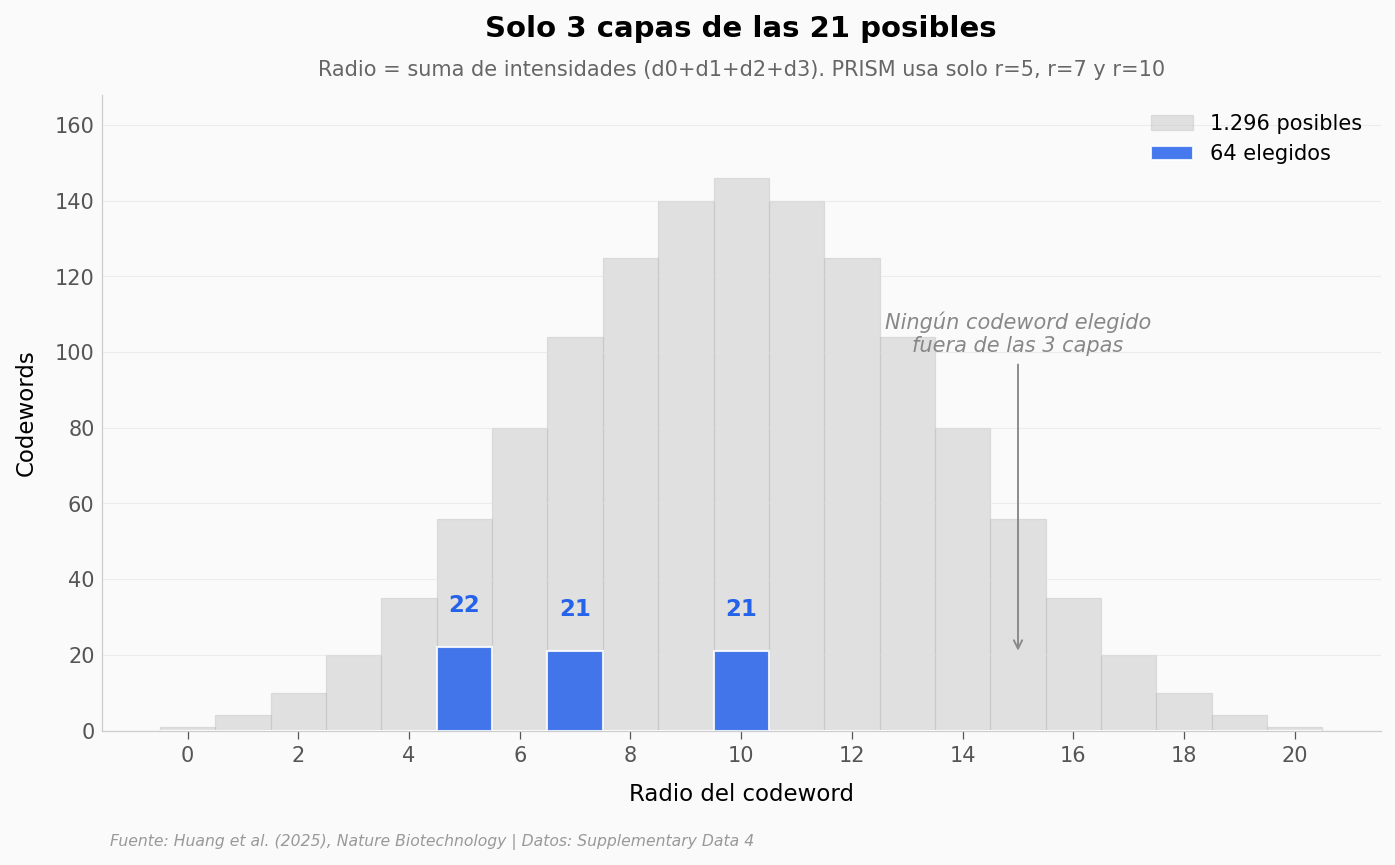

Radios posibles: 0 a 20 (21 valores únicos)
Radios usados por PRISM: [np.int64(5), np.int64(7), np.int64(10)] (3 capas)
Codewords por capa: {np.int64(5): 22, np.int64(7): 21, np.int64(10): 21}


In [5]:
# Radio (suma de intensidades) para los 1.296 posibles
radios_posibles = np.array([sum(c) for c in product(range(ALFABETO), repeat=CANALES)])
radios_64 = b64['digit_sum'].values

fig, ax = plt.subplots(figsize=(11, 5.5))

bins = np.arange(0, 22) - 0.5

# Fondo: distribución de todos los radios posibles
n_fondo, _, _ = ax.hist(radios_posibles, bins=bins, color=COLOR_GRIS,
                        alpha=0.4, edgecolor=COLOR_GRIS, linewidth=0.6,
                        label='1.296 posibles')
y_max = n_fondo.max() * 1.15
ax.set_ylim(0, y_max)

# Frente: histograma de los radios de los 64 elegidos
ax.hist(radios_64, bins=bins, color=COLOR_DATOS, alpha=0.85,
        edgecolor='white', linewidth=1.0, label='64 elegidos', zorder=5)

# Anotar las 3 capas
from collections import Counter
counts_64 = Counter(radios_64)
for r, n in sorted(counts_64.items()):
    ax.text(r, n + 8, f'{n}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=COLOR_DATOS)

# Anotaciones de 'ningun codeword aqui'
ax.annotate('Ningún codeword elegido\nfuera de las 3 capas',
            xy=(15, 20), xytext=(15, 100),
            fontsize=10, color='#888888', ha='center', style='italic',
            arrowprops=dict(arrowstyle='->', color='#888888', lw=0.9))

ax.set_title('Solo 3 capas de las 21 posibles',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Radio = suma de intensidades (d0+d1+d2+d3). PRISM usa solo r=5, r=7 y r=10',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Radio del codeword', fontsize=11)
ax.set_ylabel('Codewords', fontsize=11)
ax.set_xticks(range(0, 21, 2))
ax.legend(loc='upper right', fontsize=10)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/capas_radios.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Radios posibles: 0 a {radios_posibles.max()} ({len(np.unique(radios_posibles))} valores únicos)')
print(f'Radios usados por PRISM: {sorted(set(radios_64))} ({len(set(radios_64))} capas)')
print(f'Codewords por capa: {dict(sorted(counts_64.items()))}')


## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| PRISM ofrece hasta **64 codewords distinguibles** en una sola ronda de imagen | ✅ | 64 codewords únicos verificados en el Supplementary Data 4; separación geométrica por capas (r=5, 7, 10) |
| El **espacio posible** con 4 canales y 6 niveles es **1.296** combinaciones | ✅ | 6⁴ = 1.296; PRISM elige 64 (4,9%) y 31 (2,4%) |
| El panel 64-plex tiene **mejor separación mínima** (√2) que el 31-plex (1,0) | ✅ | 135/2.016 pares a distancia √2 en 64-plex; 15/465 pares a distancia 1,0 en 31-plex |
| El panel **HCC tumoral** usa **más sondas por gen** que los paneles de cerebro y embrión | ✅ | 30/31 genes HCC con 3 sondas (media 2,94); cerebro y embrión con 1 sonda/gen |
| Los 30 genes del panel embrión 30-plex están **preservados** en el panel embrión 64-plex | ✅ | 30/30 genes coinciden (comparación insensible a mayúsculas) |
| Cerebro y embrión 30-plex comparten solo **1 gen** en común (Gad2) | ✅ | Los paneles están optimizados para biología distinta: marcadores neuronales vs marcadores de desarrollo |
| Los datos muestran un **rol de los fibroblastos tumorales (CAFs)** en la heterogeneidad inmune del HCC | ⚠️ | El paper reporta asociación *observacional* entre CAFs y patrones de infiltración inmune. Los datos disponibles aquí no contienen imágenes ni perfiles celulares — solo diseño del panel |

> **Limitaciones:**
> - Los datos públicos del Supplementary Data 4 contienen el **diseño del código** (codewords + paneles), no las imágenes procesadas ni los perfiles celulares — esos pesan entre 150 MB y 19 GB por muestra y viven en [Zenodo](https://doi.org/10.5281/zenodo.12755414).
> - La validación biológica del método (3D atlas de embrión, paisaje tumor-normal de HCC, atlas de cerebro) se basa en análisis de imagen que este notebook no reproduce.
> - El panel 64-plex restringe el dígito `d3` a solo 3 valores {0, 2, 5} en lugar de los 6 posibles. El paper no justifica esa restricción — queda como observación.
> - La afirmación sobre los CAFs es *observacional* dentro del tumor; no es evidencia causal de que los CAFs *provoquen* cambios inmunes.

## Ahora tú

1. **¿Y si PRISM usara 5 canales en lugar de 4?** Cambia `CANALES = 5` en la celda de configuración. ¿Cuánto crece el espacio total? ¿Cómo se compara con los 64 elegidos?
2. **¿Cuáles son los 3 pares de codewords más cercanos?** Usa `dist64.argsort()` para encontrar los índices de las distancias mínimas y busca los codewords originales en `b64`.
3. **¿Por qué falta la capa r=0?** El codeword "0000" (todas las intensidades en cero) no se puede distinguir de ruido de fondo. Comprueba que no está en `b64`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 2: ¿Cuáles son los pares de codewords más cercanos?

indices_pares = list(combinations(range(len(b64)), 2))
orden = np.argsort(dist64)

print('Los 5 pares de codewords más cercanos (distancia mínima):')
print('-' * 60)
for k in orden[:5]:
    i, j = indices_pares[k]
    bc_i = b64.iloc[i]['barcode']
    bc_j = b64.iloc[j]['barcode']
    print(f'  {bc_i}  <->  {bc_j}   distancia = {dist64[k]:.3f}')

print()
print('Estos pares están a distancia √2 ≈ 1,414 — justo en el margen de seguridad')
print('que PRISM garantiza para todo el panel.')


Los 5 pares de codewords más cercanos (distancia mínima):
------------------------------------------------------------
  235  <->  145   distancia = 1.414
  145  <->  55   distancia = 1.414
  1045  <->  55   distancia = 1.414
  3022  <->  4012   distancia = 1.414
  325  <->  235   distancia = 1.414

Estos pares están a distancia √2 ≈ 1,414 — justo en el margen de seguridad
que PRISM garantiza para todo el panel.


## Fuentes

**Paper**: [High-plex spatial RNA imaging in one round with conventional microscopes using color-intensity barcoding](https://doi.org/10.1038/s41587-025-02883-7)  
*Nature Biotechnology, 2025-10-30*

**Datos (Supplementary)**: [PRISM supplementary probe and barcode tables (MOESM4_ESM.xlsx)](https://static-content.springer.com/esm/art%3A10.1038%2Fs41587-025-02883-7/MediaObjects/41587_2025_2883_MOESM4_ESM.xlsx)  
*Nature Biotechnology (Supplementary Data 4), 2025-10-30*

**Análisis complementario**: [PRISM: Analysis Related Data — README](https://doi.org/10.5281/zenodo.12755414)  
*Zenodo (PRISM_data_publication_analysis.md), 2024-07-18*

*15 afirmaciones verificadas contra estas fuentes*